In [1]:
import numpy as np
import scipy.stats
import matplotlib.pyplot as plt
import math
import pandas as pd
import matplotlib as mpl

In [2]:
# ----- DEFINE FUNCTIONS -----

def testNormal(input, alpha=0.05):
    if len(input) >= 20:
        #This function is based on D’Agostino and Pearson’s test that combines skew and kurtosis to produce an omnibus test of normality
        results = scipy.stats.normaltest(input) 
        p_values = results.pvalue
        normal_method = "D'Agostino-Pearson test (combined kurtosis + skewness)"
        if p_value > alpha: isnormal = True
        elif p_value <= alpha: isnormal = False
    else: 
        #For n<20, we have to rely on a Monte Carlo approach to test skew and kurtosis (kurtosistest is only valid n>=20) 
        rvs = lambda size: scipy.stats.norm.rvs(size=size, random_state=np.random.default_rng())
        skew_results = scipy.stats.monte_carlo_test(input, rvs, scipy.stats.skew, vectorized=True)
        kurtosis_results = scipy.stats.monte_carlo_test(input, rvs, scipy.stats.kurtosis, vectorized=True)
        p_values = [skew_results.pvalue, kurtosis_results.pvalue]
        normal_method = "Monte Carlo method (Fisher kurtosis + Fisher-Pearson skewness)"
        # data is only treated as normal if it has both normal skew and kurtosis
        if p_values[0] > 0.05 and p_values[1] > alpha: isnormal = True
        else: isnormal = False
    return isnormal, p_values, normal_method

def make_chamber_stat_plots(df,cols,fname,savefigs,printstats,ttl,ylab):
    
    xlab = ''
    
    # do normality testing and statistical testing
    df['diff'] = df['Het']-df['WT']
    isnormal, p_values, normal_method = testNormal(df['diff'])

    if isnormal:
        statsresults = scipy.stats.ttest_rel(df['Het'], df['WT']) # run a paired ttest if the data passed normality
    else:
        statsresults = scipy.stats.wilcoxon(df['Het'], y=df['WT']) # run a wilcoxon sign rank test if not
        
    if printstats:
        print(statsresults)

    pval = statsresults[1]
    if pval>palpha:
        ptxt = 'n.s.'
    elif palpha/10<pval<palpha:
        ptxt='*'
    elif palpha/100<pval<palpha/10:
        ptxt ='**'

    # make figure
    fig, ax = plt.subplots(figsize=figsz)

    # plot WT dots
    ax.plot(np.zeros(df.shape[0]), df['WT'], 'o', markerfacecolor=cols[0],markeredgecolor=cols[0],zorder=1, ms=5, mew=1, alpha = 1)
    # plot WT boxes
    boxprops = dict(linewidth=1, color=cols[0])
    medianprops = dict(linewidth=medlw, color=cols[0])
    whiskprops = dict(linewidth=1, color=cols[0],alpha=boxalpha)
    flierprops = dict(marker=fmrkr, markerfacecolor=cols[0], markersize=fmrkrsz,
                  linestyle='none', markeredgecolor=cols[0])
    if not isnormal:
        bplot = ax.boxplot(df['WT'],positions=[0+dotadj],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,flierprops=flierprops)
    else:
        tmean = np.mean(df['WT'])
        se = scipy.stats.sem(df['WT'])
        confidence = ci
        n = len(df['WT'])
        dof = n - 1  # degrees of freedom
        confidence_interval = scipy.stats.t.interval(confidence, dof, tmean, se)
        bplot = ax.boxplot(df['WT'],positions=[0+dotadj],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,usermedians=[tmean],conf_intervals=[confidence_interval],notch=True,
                          flierprops=flierprops)
    for patch in bplot['boxes']:
        patch.set_facecolor(cols[0])
        patch.set_alpha(boxalpha)

    # plot het dots
    ax.plot(np.ones(df.shape[0]), df['Het'], 'o', markerfacecolor=cols[1], markeredgecolor=cols[1],zorder=1, ms=5, mew=1, alpha = 1)
    # plot het boxes
    boxprops = dict(linewidth=1, color=cols[1])
    medianprops = dict(linewidth=medlw, color=cols[1])
    whiskprops = dict(linewidth=1, color=cols[1],alpha=boxalpha)
    flierprops = dict(marker=fmrkr, markerfacecolor=cols[1], markersize=fmrkrsz,
                  linestyle='none', markeredgecolor=cols[1])
    if not isnormal:
        bplot = ax.boxplot(df['Het'],positions=[1-dotadj],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,flierprops=flierprops)
    else:
        tmean = np.mean(df['Het'])
        se = scipy.stats.sem(df['Het'])
        confidence = ci
        n = len(df['Het'])
        dof = n - 1  # degrees of freedom
        confidence_interval = scipy.stats.t.interval(confidence, dof, tmean, se)
        bplot = ax.boxplot(df['Het'],positions=[1-dotadj],showcaps=caps,boxprops=boxprops,medianprops=medianprops,whiskerprops=whiskprops,
                           widths=bwidth,patch_artist=True,usermedians=[tmean],conf_intervals=[confidence_interval],notch=True,
                          flierprops=flierprops)
    for patch in bplot['boxes']:
        patch.set_facecolor(cols[1])
        patch.set_alpha(boxalpha)

    # plot paired lines
    for idx in df.index: ax.plot([0,1], df.loc[idx,['WT','Het']], color = 'k', linewidth = 0.5, linestyle = '-', zorder=-1)

    # plot stats test result
    bottom, top = plt.ylim()  # return the current ylim
    y, h = df.max().max() + ppad*df.max().max(), ppad
    px1 = 0+(0.5*dotadj)
    px2 = 1-(0.5*dotadj)
    ax.plot([px1, px1, px2, px2], [y, y+h, y+h, y], lw=plw, c=pcol)
    plt.text((px1+px2)*.5, y+h+0.1*h, ptxt, ha='center', va='bottom', color=pcol,size=6)

    # remove axis lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)

    # adjust labeling parameters
    ax.set_xticks([0+(0.5*dotadj),1-(0.5*dotadj)],labels=lbls)
    ax.tick_params(axis='x', which='both',length=0)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(ttl)

    # save
    if savefigs:
        plt.savefig(fname,bbox_inches='tight')
        
def make_NC_preferenceIndex_plot(df,cols,fname,savefigs,printstats,ttl,ylab,figsz):
    
    # test preference indices for normality
    isNormal = testNormal(df['prefIdx'])[0]
    
    # do stats - test for normality, find p value, find central tendency
    if isNormal:
        res = scipy.stats.ttest_1samp(df['prefIdx'], popmean = 0)
        p = m_res.pvalue
        test = '1-sample t-test, null = 0'
        ctline = np.mean(df['prefIdx']) # take measure of central tendency for plotting
    else:     
        stat, p = scipy.stats.wilcoxon(df['prefIdx'], zero_method = 'pratt')
        test = 'wilcoxon signed-rank test'
        ctline = np.median(df['prefIdx']) # take measure of central tendency for plotting
        
    if printstats:
        print(f'{test}: p = {p}')
        
    # determine stat info to put on plot
    if p>palpha:
        ptxt = 'n.s.'
    elif palpha/10<p<palpha:
        ptxt='*'
    elif palpha/100<p<palpha/10:
        ptxt ='**'        
        
    # jitter dots    
    df_jitter = pd.DataFrame(np.random.normal(loc=0, scale=jitter, size=df.values.shape), columns=df.columns)

    # make figure
    fig, ax = plt.subplots(figsize=figsz)
    
    # organize preference index with different colors depending on sign
    pref = df.reset_index().drop(labels='index',axis=1)
    wtprefIdx = pref['prefIdx']>0
    htprefIdx = pref['prefIdx']<0
      
    # plot WT dots in WT color
    ax.plot(df_jitter[wtprefIdx]['prefIdx'], pref[wtprefIdx]['prefIdx'], 'o', markerfacecolor=cols[0], 
        markeredgecolor=cols[0],zorder=1, ms=5, mew=1)
    
    # plot het dots
    ax.plot(df_jitter[htprefIdx]['prefIdx'], pref[htprefIdx]['prefIdx'], 'o', markerfacecolor=cols[1], 
        markeredgecolor=cols[1],zorder=1, ms=5, mew=1)
    
    # plot central tendency
    ax.plot([-xt/4,xt/4],[ctline,ctline],color='k',linewidth=4,zorder=-1)
    
    # plot stats test result
    bottom, top = plt.ylim()  # return the current ylim
    y, h = pref.max() + ppad*pref.max(), ppad    
    plt.text(0, y+h, ptxt, ha='center', va='bottom', color=pcol,size=6)
    
    # plot line at 0
    ax.plot([-xt/2,xt/2],[0,0],'--',color=[0.5,0.5,0.5],zorder=-1)

    # remove axis lines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.set_xticks([])
    ax.set_xlim(-jitpad,jitpad)
    
    # labels and title
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    ax.set_title(ttl,pad=15)
    
    # save
    if savefigs:
        plt.savefig(fname,bbox_inches='tight')

In [21]:
# ----- SET GLOBAL PARAMETERS -----

# matplotlib plotting defaults
mpl.rcParams['lines.linewidth'] = 2

mpl.rcParams['axes.titlesize'] = 7
mpl.rcParams['axes.labelsize'] = 6

mpl.rcParams['xtick.labelsize'] = 5
mpl.rcParams['ytick.labelsize'] = 5

plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["Arial"]

plt.rcParams['svg.fonttype'] = 'none'

# colors
acols = [[0.627451,   0.57254905, 0.37254903], # all colors
    [0.9607843,  0.7882353,  0.15294118],
    [0.34901962, 0.35686275, 0.49019608],
    [0.24705882, 0.30588236, 0.9607843 ]]

fcols = acols[0:2] # female colors, WT first
mcols = acols[2:] # male colors, WT first

# stats and plotting params
csz = 0 # !!!
ewd = 1 # !!!
dotadj = -0.5 # offset for dots from boxplot position
ebaradj = 0.15 # !!!
barline = 0.5 # !!!

# outlier flier marker properties
fmrkr = 'x'
fmrkrsz = 4

figsz = (1,2) # total size of figure
boxalpha = 0.5 # transparency for boxplot face color

boxlw = 1 # boxplot linewidth
medlw = 1.5 # median linewidth
bwidth = 0.25 # box width
caps = False # don't put caps on the error bars

ppad = 0.085 # size of pvalue offset and height of bracket legs
plw = 0.8 # line thickness for pvalue bracket
pcol = 'k' # color for pvalue bracket
palpha = 0.05 # threshold for significance

ci = 0.95 # normal data box plot confidence interval

# parameters for naive choice index plots
xt = 0.3 # x adjustment for jitter
jitter = 0.04 # jitter value
jitpad = jitter*4 # how much x axis padding to have around the jitter value

# data management
na_column = "Unknown_sec"

In [14]:
# ----- LOAD DATA -----
NC_chambertime = pd.read_csv('combinedChamberTime_241205.csv',index_col = 0)
data_df = NC_chambertime.copy()
savefigs = True
NC_chambertime.head(5)

,NC,Het_Sex,Het_Side,Center_ct,Center_lat,Center_prop,Center_sec,Huddle_Center_ct,Huddle_Center_lat,Huddle_Center_prop,...,WT_sec,Huddle_HT_ct,Huddle_HT_lat,Huddle_HT_prop,Huddle_HT_sec,HT_ct,HT_lat,HT_prop,HT_sec,Huddle_geno_PI
NC1,1,M,Left,68,0.0,0.023886,517.466664,0,0,0.000000,...,639.850000,696,373.383333,0.745278,16145.683310,716,372.083333,0.946579,20506.650010,-0.954287
NC2,2,M,Right,129,0.0,0.060288,1305.050008,0,0,0.000000,...,14543.299990,469,40.400000,0.013590,294.183379,493,47.350000,0.267866,5798.450005,0.948025
NC4,4,F,Right,338,0.0,0.112434,2447.416667,0,0,0.000000,...,12393.633330,994,577.666667,0.133795,2912.400000,1111,89.883333,0.318206,6926.600000,0.446484
NC5,5,F,Left,192,0.0,0.049301,1072.816667,0,0,0.000063,...,16344.050000,731,51.666667,0.128282,2791.483333,787,49.833333,0.199610,4343.616667,0.584727
NC6,6,F,Left,260,0.0,0.068117,1481.516676,0,0,0.000000,...,3210.866658,946,81.383333,0.626685,13630.199980,1040,75.450000,0.784255,17057.300000,-0.909729


Ttest_relResult(statistic=0.3555010285614915, pvalue=0.7289375714287247)


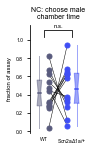

In [22]:
# ----- PLOT MALES, CHAMBER TIME -----

# configure data...
     
metric = 'prop'
wt_col = 'WT_'+metric
het_col = 'HT_'+metric
na_column = "Unknown_sec"

printstats = True
sex = 'male'
stat = 'chamber time'
statr = stat.replace(' ','-')
lbls = ['WT','Scn2a$ \Delta $1a/+']
fname = f'naiveChoice_chamber-data_choose-{sex}_{statr}.svg'

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# Exclude rows that don't meet NA criteria and are sex-specific
df = pd.DataFrame({'WT': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][wt_col], 
                            'Het': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][het_col]})

# make label and title
ylab = 'fraction of assay'
ttl = f'NC: choose {sex}\n{stat}'

make_chamber_stat_plots(df,cols,fname,savefigs,printstats,ttl,ylab)

WilcoxonResult(statistic=43.0, pvalue=0.892578125)


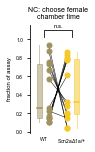

In [23]:
# ----- PLOT FEMALES, CHAMBER TIME -----

# configure data...
     
metric = 'prop'
wt_col = 'WT_'+metric
het_col = 'HT_'+metric
na_column = "Unknown_sec"

printstats = True
sex = 'female'
stat = 'chamber time'
statr = stat.replace(' ','-')
lbls = ['WT','Scn2a$ \Delta $1a/+']
fname = f'naiveChoice_chamber-data_choose-{sex}_{statr}.svg'

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# Exclude rows that don't meet NA criteria and are sex-specific
df = pd.DataFrame({'WT': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][wt_col], 
                            'Het': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][het_col]})

# make label and title
ylab = 'fraction of assay'
ttl = f'NC: choose {sex}\n{stat}'

make_chamber_stat_plots(df,cols,fname,savefigs,printstats,ttl,ylab)

Ttest_relResult(statistic=0.7290026645158401, pvalue=0.481233750496039)


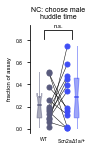

In [28]:
# ----- PLOT MALES, HUDDLE TIME -----

# configure data...
     
metric = 'prop'
wt_col = 'Huddle_WT_'+metric
het_col = 'Huddle_HT_'+metric
na_column = "Unknown_sec"

printstats = True
sex = 'male'
stat = 'huddle time'
statr = stat.replace(' ','-')
lbls = ['WT','Scn2a$ \Delta $1a/+']
fname = f'naiveChoice_huddle-data_choose-{sex}_{statr}.svg'

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# Exclude rows that don't meet NA criteria and are sex-specific
df = pd.DataFrame({'WT': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][wt_col], 
                            'Het': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][het_col]})

# make label and title
ylab = 'fraction of assay'
ttl = f'NC: choose {sex}\n{stat}'

make_chamber_stat_plots(df,cols,fname,savefigs,printstats,ttl,ylab)

WilcoxonResult(statistic=29.0, pvalue=0.2734375)


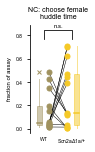

In [24]:
# ----- PLOT FEMALES, HUDDLE TIME -----

# configure data...
     
metric = 'prop'
wt_col = 'Huddle_WT_'+metric
het_col = 'Huddle_HT_'+metric
na_column = "Unknown_sec"

printstats = True
sex = 'female'
stat = 'huddle time'
statr = stat.replace(' ','-')
lbls = ['WT','Scn2a$ \Delta $1a/+']
fname = f'naiveChoice_huddle-data_choose-{sex}_{statr}.svg'

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

# Exclude rows that don't meet NA criteria and are sex-specific
df = pd.DataFrame({'WT': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][wt_col], 
                            'Het': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)][het_col]})

# make label and title
ylab = 'fraction of assay'
ttl = f'NC: choose {sex}\n{stat}'

make_chamber_stat_plots(df,cols,fname,savefigs,printstats,ttl,ylab)

wilcoxon signed-rank test: p = 1.0


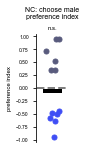

In [26]:
# ----- PLOT MALES, PREFERENCE INDEX -----

# configure data
printstats = True
sex = 'male'
stat = 'preference index'
statr = stat.replace(' ','-')
fname = f'naiveChoice_huddle-data_choose-{sex}_{statr}.svg'

lbls = ['WT','Scn2a$ \Delta $1a/+']
xlab = ''
ylab = 'preference index'
ttl = f'NC: choose {sex}\n{stat}'
smallfig = (0.6,2)

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

df = pd.DataFrame({'prefIdx': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)]['Huddle_geno_PI']})

make_NC_preferenceIndex_plot(df,cols,fname,savefigs,printstats,ttl,ylab,smallfig)

wilcoxon signed-rank test: p = 0.7353515625


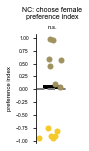

In [27]:
# ----- PLOT FEMALES, PREFERENCE INDEX -----

# configure data
printstats = True
sex = 'female'
stat = 'preference index'
statr = stat.replace(' ','-')
fname = f'naiveChoice_huddle-data_choose-{sex}_{statr}.svg'

lbls = ['WT','Scn2a$ \Delta $1a/+']
xlab = ''
ylab = 'preference index'
ttl = f'NC: choose {sex}\n{stat}'
smallfig = (0.6,2)

# select data and colors
if sex=='male':
    cols = mcols
    sexlet = 'M'
else:
    cols = fcols
    sexlet = 'F'

df = pd.DataFrame({'prefIdx': data_df[(data_df['Het_Sex']==sexlet)& (data_df[na_column]<60)]['Huddle_geno_PI']})

make_NC_preferenceIndex_plot(df,cols,fname,savefigs,printstats,ttl,ylab,smallfig)